#PROJECT INTRODUCTION

# MailShield Pro

## Smart Message Intelligence System

MailShield Pro is a machine learning-based message analysis platform that categorizes messages, evaluates risk levels, and helps users identify important communications while filtering suspicious content.

#PROBLEM STATEMENT



Students and professionals receive hundreds of messages daily.

Important internship, placement, and academic notifications often get mixed with promotional and suspicious content.

The objective is to build a system that not only detects spam but also prioritizes important messages and evaluates message risk.

#IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

plt.style.use('dark_background')

#LOAD DATASET

In [ ]:
df=pd.read_csv("/content/spam.csv",encoding='latin-1')

#REQUIRED COLUMNS

In [ ]:
df = df[['v1', 'v2']]

#RENAME COLUMNS

In [ ]:
df.columns = ['label', 'message']


In [ ]:

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#DATASET AUDIT

In [ ]:
overview = pd.DataFrame({
    "Metric": [
        "Total Messages",
        "Spam Messages",
        "Safe Messages",
        "Missing Values"
    ],
    "Value": [
        len(df),
        len(df[df['label']=='spam']),
        len(df[df['label']=='ham']),
        df.isnull().sum().sum()
    ]
})

overview

,Metric,Value
0,Total Messages,5572
1,Spam Messages,747
2,Safe Messages,4825
3,Missing Values,0


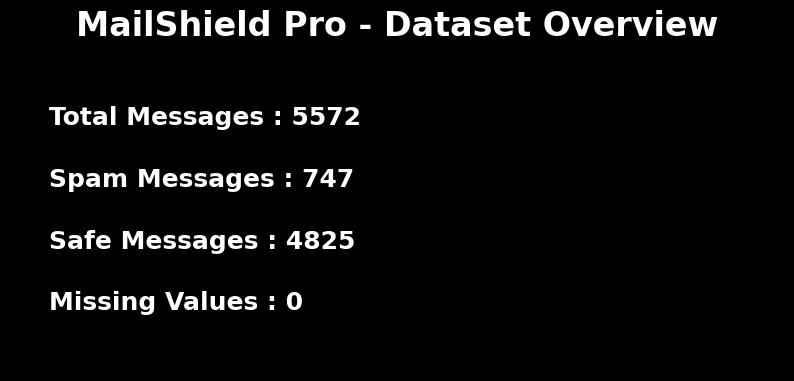

In [ ]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10,4))
plt.axis('off')

plt.text(0.05, 0.8,
         f"Total Messages : {len(df)}",
         fontsize=18,
         fontweight='bold')

plt.text(0.05, 0.6,
         f"Spam Messages : {len(df[df['label']=='spam'])}",
         fontsize=18,
         fontweight='bold')

plt.text(0.05, 0.4,
         f"Safe Messages : {len(df[df['label']=='ham'])}",
         fontsize=18,
         fontweight='bold')

plt.text(0.05, 0.2,
         f"Missing Values : {df.isnull().sum().sum()}",
         fontsize=18,
         fontweight='bold')

plt.title(
    "MailShield Pro - Dataset Overview",
    fontsize=24,
    fontweight='bold',
    pad=20
)

plt.savefig(
    "dataset_overview.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#LABEL ENCODING

In [ ]:

df['target'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


#MESSAGE LENGTH FEATURE

In [ ]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,target,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


#BAR CHART

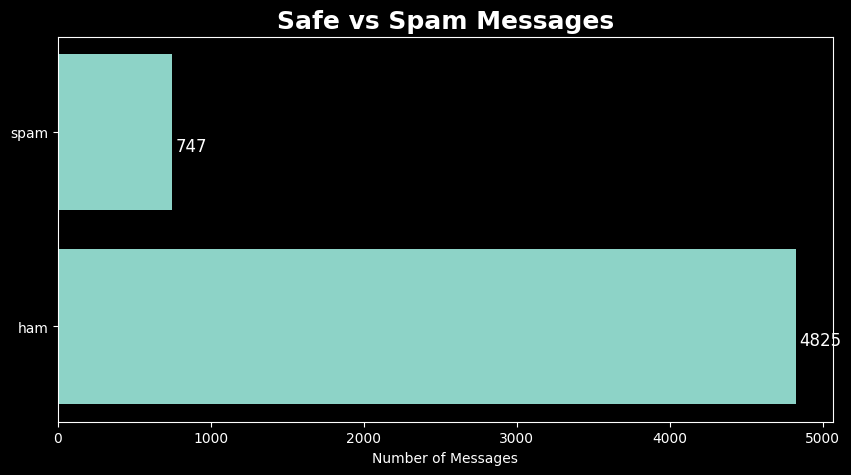

In [ ]:
counts = df['label'].value_counts()

plt.figure(figsize=(10,5))

bars = plt.barh(
    counts.index,
    counts.values
)

plt.title(
    "Safe vs Spam Messages",
    fontsize=18,
    fontweight='bold'
)

for bar in bars:
    plt.text(
        bar.get_width()+20,
        bar.get_y()+0.3,
        str(int(bar.get_width())),
        fontsize=12
    )

plt.xlabel("Number of Messages")
plt.savefig("message_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

#MESSAGE LENGTH ANALYSIS

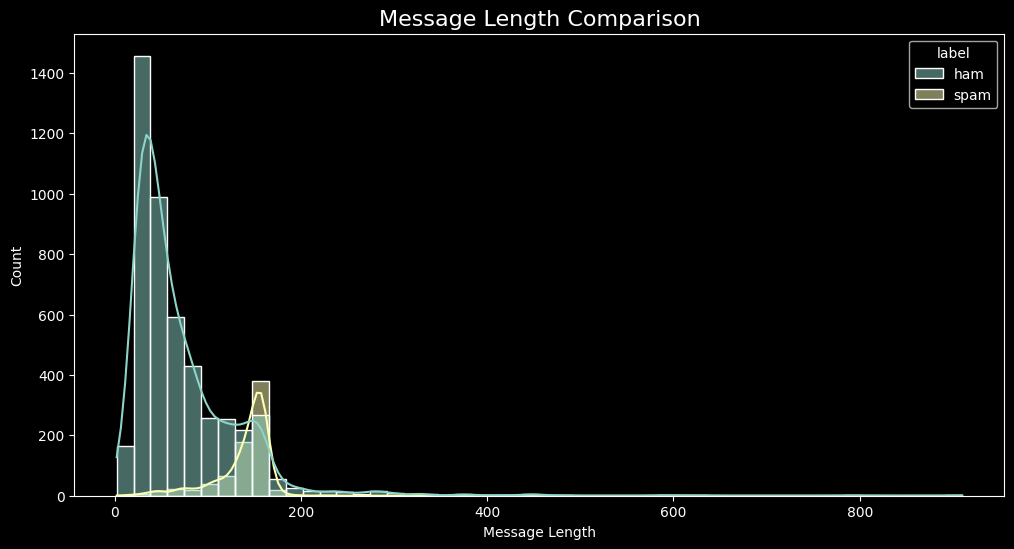

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50,
    kde=True
)

plt.title(
    "Message Length Comparison",
    fontsize=16
)

plt.xlabel("Message Length")
plt.savefig("message_length.png", dpi=300, bbox_inches='tight')

plt.show()

#TEXT CLEANING

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'http\S+',
        '',
        text
    )

    text = re.sub(
        r'\d+',
        '',
        text
    )

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    return text

In [ ]:
df['clean_message'] = df['message'].apply(
    clean_text
)

df.head()

,label,message,target,message_length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,0,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,0,49,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,nah i dont think he goes to usf he lives aroun...


#SPAM WORD CLOUD

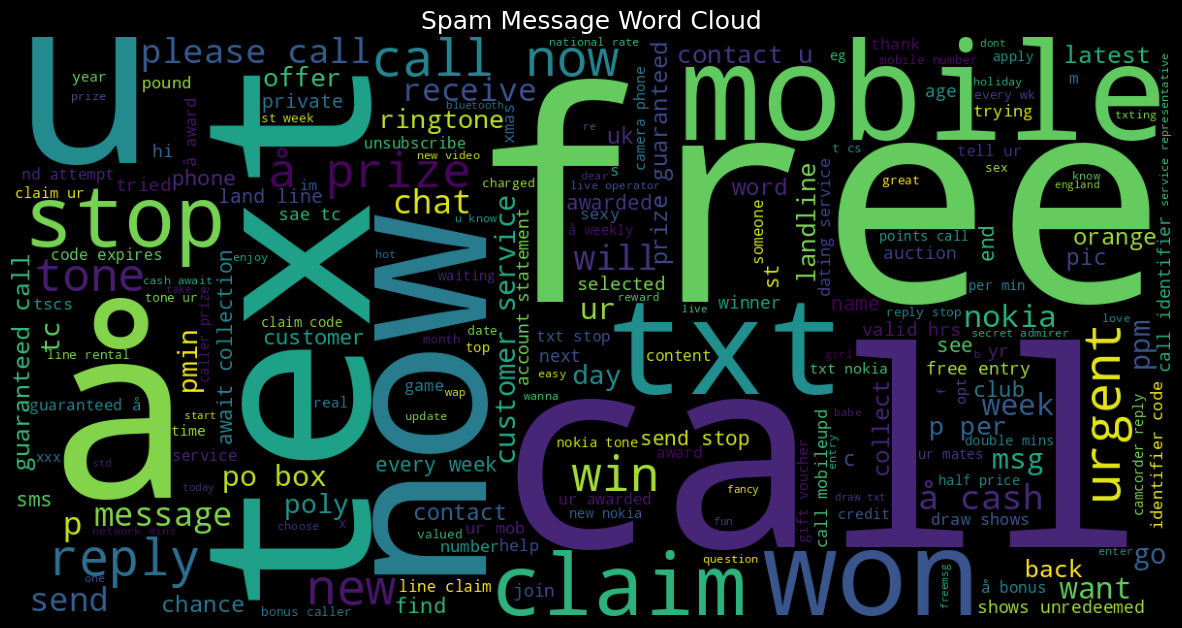

In [ ]:
spam_text = " ".join(
    df[df['label']=='spam']['clean_message']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black'
).generate(spam_text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title(
    "Spam Message Word Cloud",
    fontsize=18
)
plt.savefig("spam_wordcloud.png", dpi=300, bbox_inches='tight')

plt.show()

#SAFE MESSAGE WORD CLOUD

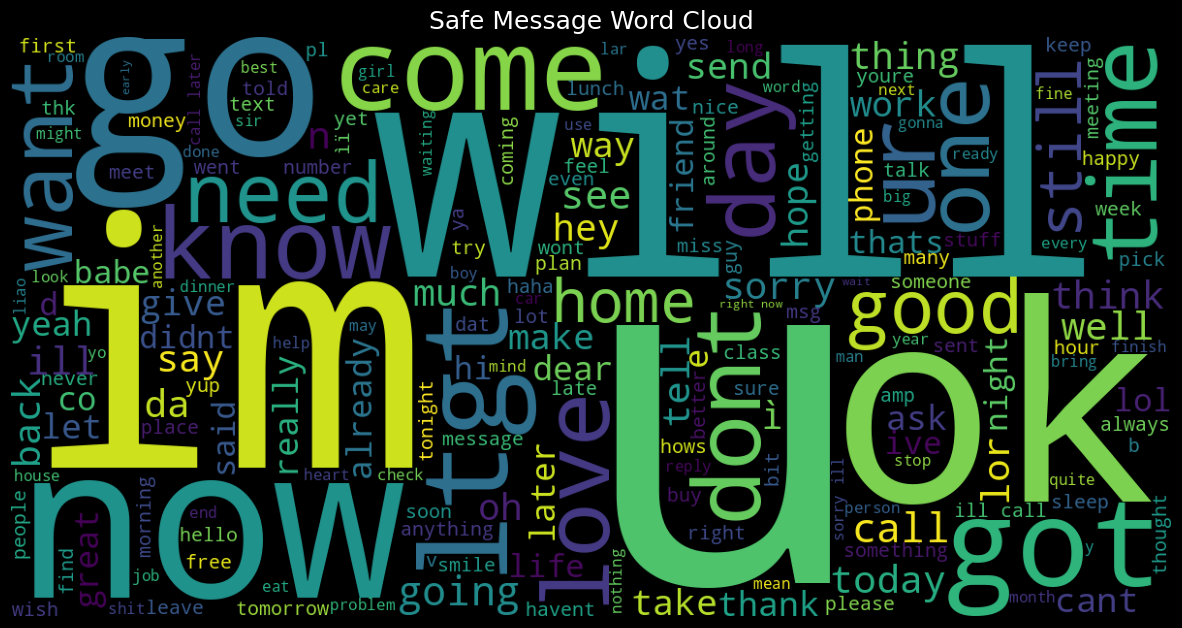

In [ ]:
ham_text = " ".join(
    df[df['label']=='ham']['clean_message']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black'
).generate(ham_text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title(
    "Safe Message Word Cloud",
    fontsize=18
)

plt.show()

#RISK ASSESMENT ENGINE

In [ ]:
risk_words = {

    "free":15,
    "winner":15,
    "won":15,
    "claim":15,
    "reward":15,
    "cash":15,
    "urgent":10,
    "click":15,
    "offer":10,
    "prize":15
}

#RISK CALCULATOR

In [ ]:
def calculate_risk(message):

    score = 0

    indicators = []

    message = message.lower()

    for word, value in risk_words.items():

        if word in message:

            score += value

            indicators.append(word)

    if "http" in message:

        score += 20

        indicators.append("link detected")

    score = min(score,100)

    return score, indicators

#TESTING RISK ENGINE

In [ ]:
msg = """
Congratulations!
You have won ₹10000.
Click here now to claim your reward.
"""

risk, indicators = calculate_risk(msg)

print("Risk Score :", risk)

print("\nIndicators Found:")

for item in indicators:
    print("✓", item)

Risk Score : 60

Indicators Found:
✓ won
✓ claim
✓ reward
✓ click


### Feature Engineering using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(
    df['clean_message']
)

y = df['target']

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5572, 5000)


### Splitting Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 4457
Testing Samples: 1115


### Training Classification Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

print("Model Training Completed")

Model Training Completed


#Model Prediction

In [ ]:
predictions = model.predict(
    X_test
)

predictions[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

#Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"MailShield Accuracy: {accuracy*100:.2f}%"
)

MailShield Accuracy: 97.04%


## Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.78      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## Confusion Matrix

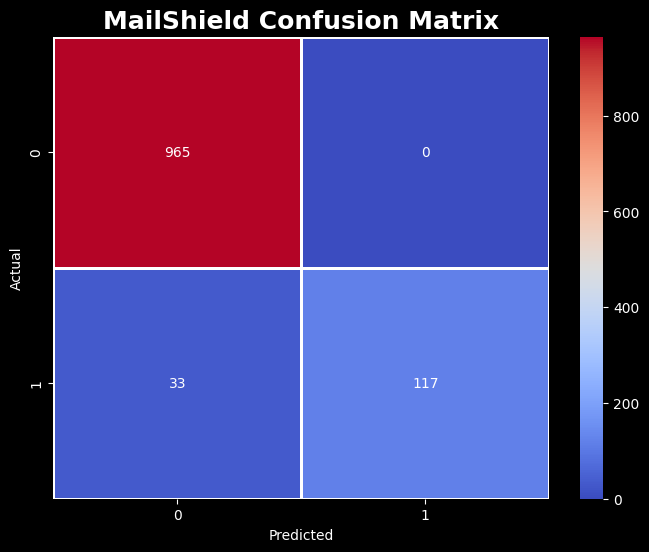

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    linewidths=2,
    cbar=True
)

plt.title(
    "MailShield Confusion Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

### Top Threat Keywords

In [ ]:
from collections import Counter

spam_words = []

for msg in df[df['label']=='spam']['clean_message']:

    spam_words.extend(msg.split())

word_counts = Counter(
    spam_words
)

top_words = word_counts.most_common(15)

top_df = pd.DataFrame(
    top_words,
    columns=['Word','Count']
)

top_df

,Word,Count
0,to,686
1,a,377
2,call,349
3,you,287
4,å£,270
5,your,263
6,free,219
7,the,204
8,for,203
9,now,190


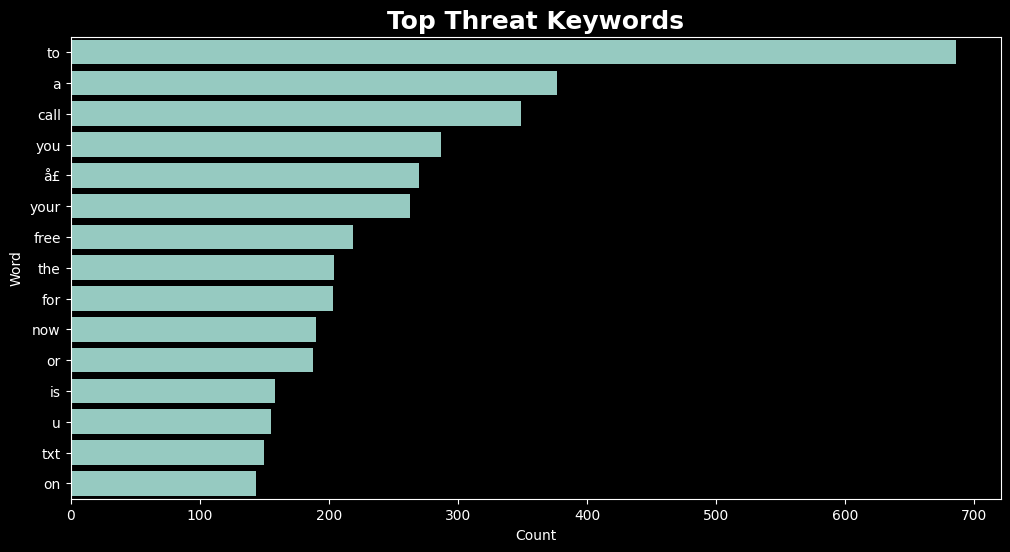

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_df,
    x='Count',
    y='Word'
)

plt.title(
    "Top Threat Keywords",
    fontsize=18,
    fontweight='bold'
)
plt.savefig("top_threat_words.png", dpi=300, bbox_inches='tight')

plt.show()

## Message Prioritization Engine

In [ ]:
important_words = [

    "interview",
    "internship",
    "placement",
    "exam",
    "selection",
    "tcs",
    "job",
    "offer letter"
]

promo_words = [

    "discount",
    "sale",
    "offer",
    "coupon",
    "deal",
    "premium"
]

#Classification Function

In [ ]:
def classify_priority(message):

    msg = message.lower()

    for word in important_words:

        if word in msg:
            return "Important"

    for word in promo_words:

        if word in msg:
            return "Promotional"

    risk,_ = calculate_risk(message)

    if risk > 50:
        return "Spam"

    return "Safe"

#Text Priority Engine

In [ ]:
test_messages = [

    "Your TCS NQT exam is tomorrow",

    "Get 50% discount on premium courses",

    "Congratulations you won a cash reward",

    "Let's meet tomorrow"
]

for msg in test_messages:

    print("\nMessage:", msg)

    print(
        "Category:",
        classify_priority(msg)
    )


Message: Your TCS NQT exam is tomorrow
Category: Important

Message: Get 50% discount on premium courses
Category: Promotional

Message: Congratulations you won a cash reward
Category: Safe

Message: Let's meet tomorrow
Category: Safe


## Live Message Analyzer

In [ ]:
message = input("Enter Message: ")

cleaned = clean_text(message)

vector = vectorizer.transform([cleaned])

prediction = model.predict(vector)

risk, indicators = calculate_risk(message)

priority = classify_priority(message)

print("\n" + "="*60)
print("🛡️ MAILSHIELD PRO - SECURITY REPORT")
print("="*60)

print(f"\n📂 Category      : {priority}")
print(f"⚠️ Risk Score    : {risk}/100")

print("\n🔍 Threat Indicators:")

if len(indicators) == 0:
    print("No suspicious indicators detected")
else:
    for item in indicators:
        print("✓", item)

print(f"\n🤖 ML Prediction : {'SPAM' if prediction[0]==1 else 'SAFE'}")

print("\n📝 Recommendation:")

if risk > 50:
    print("Avoid interacting with this message.")
elif risk > 20:
    print("Exercise caution before responding.")
else:
    print("Message appears safe.")

print("\n" + "="*60)

Enter Message: congratulations u have won rupees10,000 cash prize

🛡️ MAILSHIELD PRO - SECURITY REPORT

📂 Category      : Safe
⚠️ Risk Score    : 45/100

🔍 Threat Indicators:
✓ won
✓ cash
✓ prize

🤖 ML Prediction : SPAM

📝 Recommendation:
Exercise caution before responding.



#Model Saving

In [ ]:
import pickle

pickle.dump(
    model,
    open(
        'mailshield_model.pkl',
        'wb'
    )
)

pickle.dump(
    vectorizer,
    open(
        'vectorizer.pkl',
        'wb'
    )
)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

MailShield Pro successfully classifies messages into Safe and Spam categories using Machine Learning.

The system further enhances security through a custom Risk Assessment Engine and Message Prioritization Layer.

Features include:

- Spam Detection
- Risk Scoring
- Threat Indicator Analysis
- Message Prioritization
- Interactive Message Analysis

The project demonstrates how machine learning can be used to improve communication security and message management.